In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from experiments.plotting import _plot_SRE_distribution, view_correlation

from src.utils import configure_logger
from GNN.training.utils import to_scalar
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from GNN.training.utils import collect_dataset_indices
from GNN.physics_aware_NN import ShardedQuantumCircuitGraphDataset

In [4]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [5]:
def dataset_to_dataframe(dataset):
    data = []
    keep_fields = ["n_qubits", "n_layers", "sre", "seed", "family"]
    for item in dataset:
        row = {}
        for field in keep_fields:
            if not hasattr(item, field):
                continue

            value = getattr(item, field)
            if field == "family":
                # Keep categorical label as text (e.g., "clifford")
                row[field] = str(value)
            else:
                row[field] = to_scalar(value)
        data.append(row)

    df = pd.DataFrame(data)

    int_cols = ["n_qubits", "n_layers", "seed"]
    for col in int_cols:
        if col in df.columns:
            df[col] = df[col].astype(int)

    float_cols = ["sre"]
    for col in float_cols:
        if col in df.columns:
            df[col] = df[col].astype(float)

    if "family" in df.columns:
        df["family"] = df["family"].astype(str)

    return df

In [6]:
target_variant = "sre"
family = "random"
# regime_type = "identity_like"
regime_type = "saturated"

index_path = collect_dataset_indices(
    "../outputs/data/datasets_SRE",
    family=family,
)
print(f"Collected {len(index_path)} dataset indices for family '{family}' and regime '{regime_type}'")
base_dataset = ShardedQuantumCircuitGraphDataset(
    index_paths=index_path,
    target_variant=target_variant,
    split="all",
    cache_size=64,
)
df = dataset_to_dataframe(base_dataset)

plot_df = df[
    (df["sre"].notna())
]

avg_df = (
    plot_df
    .groupby(["n_qubits", "n_layers", "family"])
    .agg(
        sre_mean=("sre", "mean"),
        sre_std=("sre", "std"),
    )
    .reset_index()
)

avg_df.to_csv(f"final/data/avg_sre_{family}.csv", index=False)

Collected 1 dataset indices for family 'random' and regime 'saturated'


In [7]:
df.head()

,n_qubits,n_layers,sre,seed,family
0,4,1,0.202442,22550440,random
1,4,1,0.000129,25064164,random
2,4,1,0.682258,35019855,random
3,4,1,0.412548,35413194,random
4,4,1,0.374010,42486639,random


In [8]:
df_random = df[df["family"] == "random"].copy()
print(df_random["sre"].describe())
print("target_variant:", df_random["sre"].var())
print("Std:", df_random["sre"].std())

df_random.groupby("n_qubits")["sre"].agg(
    ["count", "mean", "std", "var"],
)

count    3.570000e+04
mean     3.400162e+00
std      2.365550e+00
min     -2.562741e-15
25%      1.638032e+00
50%      3.153243e+00
75%      5.348991e+00
max      8.013436e+00
Name: sre, dtype: float64
target_variant: 5.595829062325704
Std: 2.365550477653289


,count,mean,std,var
n_qubits,,,,
4,8925,1.631783,0.821712,0.675211
6,8925,2.799404,1.459088,2.128938
8,8925,3.984315,2.131372,4.542746
10,8925,5.185146,2.832321,8.022040
12,0,NaN,NaN,NaN
14,0,NaN,NaN,NaN
16,0,NaN,NaN,NaN
18,0,NaN,NaN,NaN
20,0,NaN,NaN,NaN


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = predictions_df["true"].to_numpy()
y_pred = predictions_df["pred"].to_numpy()

mean_pred = np.full_like(y_true, y_true.mean())

print("Model MSE:", mean_squared_error(y_true, y_pred))
print("Mean baseline MSE:", mean_squared_error(y_true, mean_pred))

print("Model MAE:", mean_absolute_error(y_true, y_pred))
print("Mean baseline MAE:", mean_absolute_error(y_true, mean_pred))

print("Model R2:", r2_score(y_true, y_pred))

NameError: name 'predictions_df' is not defined

### Training

In [10]:
model_type="gnn"
epochs = 10
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "quansistor"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [ ]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_type=model_type,
    model_hparams=None,
    train_hparams=None,
    training_data_dir=training_data_dir,
    split=split,
    model_save_path=model_save_path,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

2026-06-22 09:39:07,105 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=quansistor | loss_type=huber
2026-06-22 09:39:07,111 - GNN.training.runners - INFO - Training configuration done.
2026-06-22 09:39:07,111 - GNN.training.runners - INFO - Collecting data paths...
2026-06-22 09:39:07,113 - GNN.training.runners - INFO - Found 1 data paths.
2026-06-22 09:39:07,114 - GNN.training.runners - INFO - Data paths collected.
2026-06-22 09:39:07,114 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...


{'gnn_hidden': 128, 'gnn_heads': 8, 'global_hidden': 16, 'reg_hidden': 64, 'num_layers': 3, 'dropout_rate': 0.4050959484660077}
{'weight_decay': 0.0006626449388616718, 'grad_clip': 4.779019014790367, 'early_stopping_patience': 15, 'early_stopping_min_delta': 0.0, 'num_workers': 0}


2026-06-22 09:41:44,350 - GNN.training.runners - INFO - Loaders and model built.
2026-06-22 09:41:44,351 - GNN.training.runners - INFO - Starting training...
2026-06-22 09:41:44,352 - GNN.training.train - INFO - Using device: cuda
2026-06-22 09:41:44,557 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/10:  24%|██▍       | 196/804 [01:00<03:05,  3.28it/s, loss=0.0484, graphs=6304]

2026-06-22 09:42:44,653 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 197/804 | loss 0.048350 | elapsed 60.1s | graphs 6304


...

Epoch 1/10:  74%|███████▍  | 593/804 [03:00<01:10,  3.00it/s, loss=0.0350, graphs=19008]

2026-06-22 09:44:45,069 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 594/804 | loss 0.035048 | elapsed 180.5s | graphs 19008


Epoch 1/10:  98%|█████████▊| 791/804 [04:00<00:04,  3.05it/s, loss=0.0321, graphs=25344]

2026-06-22 09:45:45,317 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 792/804 | loss 0.032148 | elapsed 240.8s | graphs 25344


2026-06-22 09:45:49,373 - GNN.training.train - INFO - Training complete (244.8s) | running validation...


In [ ]:
training_scope = "family" if training_mode == "per_family" else "global"
model_save_path = model_save_path
predictions(
    model_path=model_save_path,
    model_kind=model_type,
    training_scope=training_scope,
    target_variant=target_variant,
    loss_type=loss_type,
    model_family=family,
    dataset_root=training_data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=plot_layers,
    plot_n_qubits=plot_qubits,
    split_by_family=True,
    show_progress=True,
)

2026-06-19 17:21:00,025 - scripts.predictions - INFO - Loading checkpoint: ../notebooks/outputs/models/final/random_model_gnn_per_family_sre_density.pt
2026-06-19 17:21:00,041 - scripts.predictions - INFO - Found 1 prediction files
Predicting (gnn): 100%|██████████| 7810/7810 [16:11<00:00,  8.04batch/s]
2026-06-19 17:37:53,061 - scripts.predictions - INFO - Saved 124950 predictions to outputs/predictions/family/gnn_predictions_random.csv


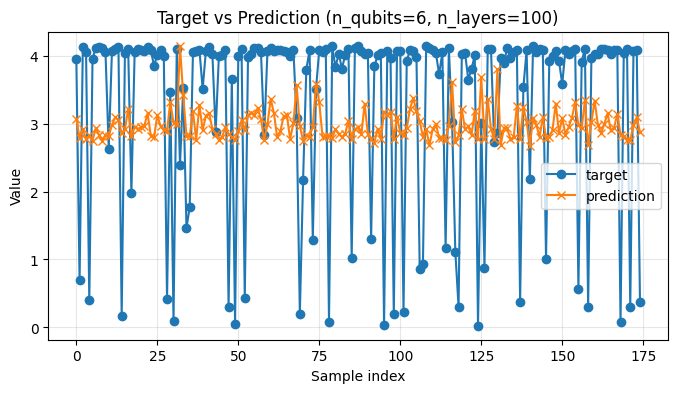

Pearson r = 0.2195


Text(0.5, 1.0, 'True vs Predicted SRE for Quansistor Family (GNN Model)')

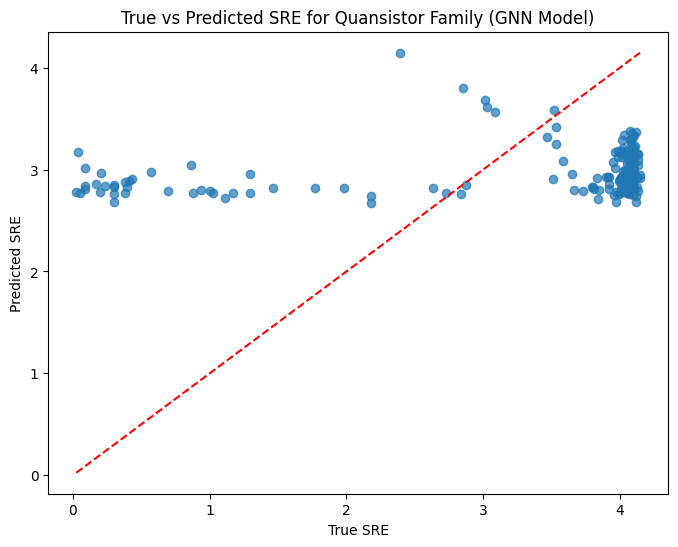

: 

In [ ]:
df = pd.read_csv(f"outputs/predictions/family/gnn_predictions_{family}.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

nq=plot_qubits
nl=plot_layers

view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target_SRE",
    col_y="predicted_SRE",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target_SRE"], df["predicted_SRE"], alpha=0.7)
plt.plot([df["target_SRE"].min(), df["target_SRE"].max()], [df["target_SRE"].min(), df["target_SRE"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Quansistor Family (GNN Model)")